# Análise e Previsão de Preços de Aluguer - AirBnB

Este projeto procura construir um modelo preditivo capaz de estimar o preço de alojamentos no AirBnB, com base em diversas características (features) da listagem, como o tipo de quarto, localização e disponibilidade.

Os *insights* retirados deste tipo de modelo são valiosos para vários públicos:
* **Anfitriões (Hosts):** Para definirem preços competitivos e maximizarem receitas.
* **Hóspedes (Guests):** Para encontrarem as melhores ofertas.
* **Investidores Imobiliários e Urbanistas:** Para compreenderem as tendências do mercado habitacional local.

In [27]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuração visual para os gráficos
sns.set_theme(style="whitegrid")

## 1. Carregamento dos Dados
Vamos carregar o conjunto de dados e visualizar as primeiras linhas.


In [41]:
#importar os dados
df = pd.read_csv('dataSP23.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


## 1.1. Análise Exploratória dos dados

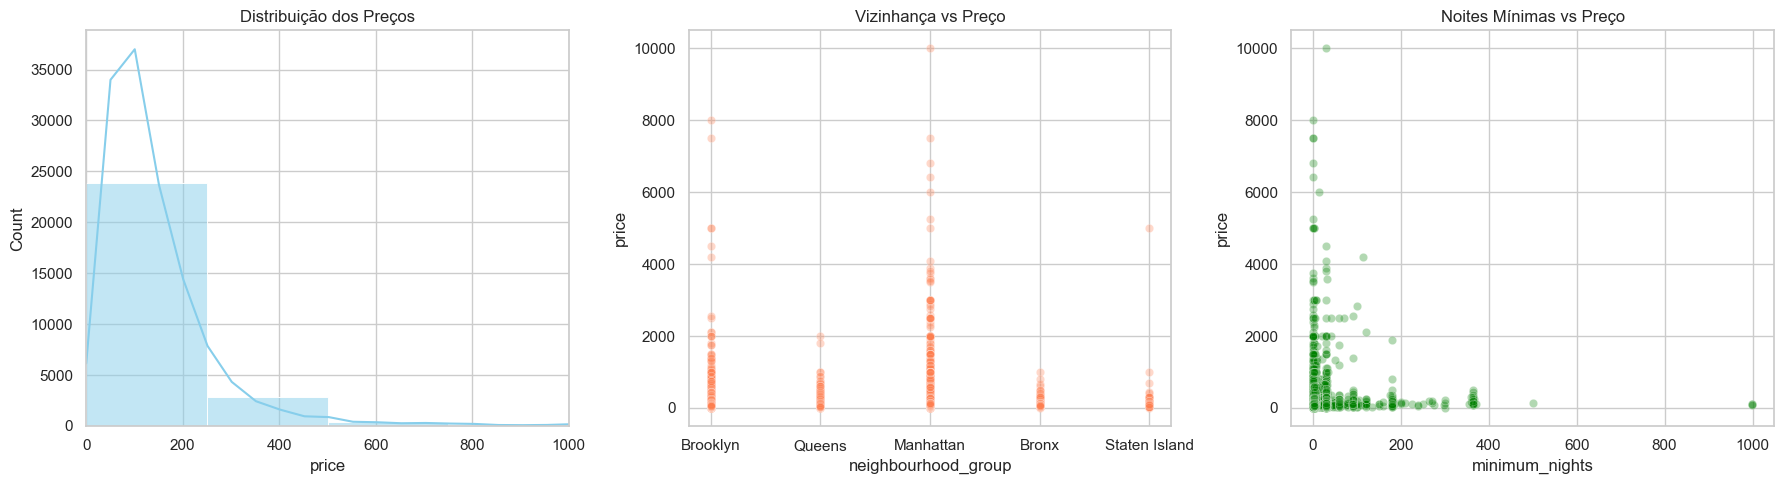

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,27379.000000,2.737900e+04,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,21746.000000,27379.000000,27379.000000
mean,13690.000000,6.820276e+07,40.728836,-73.952071,151.569561,7.056722,23.228131,1.383797,7.228788,113.430293
std,7903.780846,7.910462e+07,0.054629,0.046278,219.807784,20.194945,44.281418,1.714116,33.173634,132.039807
min,1.000000,2.438000e+03,40.506410,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,6845.500000,7.971896e+06,40.689955,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,13690.000000,3.114212e+07,40.723030,-73.955700,105.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,20534.500000,1.074344e+08,40.763045,-73.935830,175.000000,5.000000,23.000000,2.030000,2.000000,230.000000
max,27379.000000,2.743213e+08,40.913060,-73.717950,10000.000000,999.000000,607.000000,58.500000,327.000000,365.000000


In [42]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição Geral do Preço
sns.histplot(df['price'], bins=40, ax=axs[0], color='skyblue', kde=True)
axs[0].set_title('Distribuição dos Preços')
axs[0].set_xlim(0, 1000) # Limitar a 1000 para facilitar a visualização (corta os outliers extremos)

# 2. Relação: Grupo de Vizinhança vs Preço
sns.scatterplot(data=df, x='neighbourhood_group', y='price', ax=axs[1], alpha=0.3, color='coral')
axs[1].set_title('Vizinhança vs Preço')

# 3. Relação: Noites Mínimas vs Preço
sns.scatterplot(data=df, x='minimum_nights', y='price', ax=axs[2], alpha=0.3, color='green')
axs[2].set_title('Noites Mínimas vs Preço')

plt.tight_layout()
plt.show()

# Estatísticas descritivas do conjunto de dados
display(df.describe())

## 2. Limpeza e Pré-processamento
Nesta fase, vamos remover colunas que não contribuem diretamente para a previsão matemática do preço. Identificadores únicos (`id`, `host_id`) e texto livre (`name`, `host_name`) não acrescentam valor preditivo a um modelo de regressão linear simples.

In [ ]:
# Definir as colunas a descartar
colunas_a_remover = ['id', 'name', 'host_id', 'host_name', 'last_review', 'number_of_reviews', 'reviews_per_month', 'neighbourhood']
df = df.drop(columns=colunas_a_remover, errors='ignore')


print("Valores nulos por coluna:\n", df.isnull().sum())
print("\nTotal de linhas duplicadas:", df.duplicated().sum())
print("\nDimensão do dataset (linhas, colunas):", df.shape)

Valores nulos por coluna:
 neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Total de linhas duplicadas: 0

Dimensão do dataset (linhas, colunas): (27379, 8)


## 3. Deteção de Outliers 
Valores extremos no preço (propriedades incrivelmente caras, por exemplo) podem enviesar o modelo.

In [44]:
# Calcular os quartis e o IQR para a variável 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Definir o limite máximo aceitável
limite_superior = Q3 + (1.5 * IQR)

# Filtrar o dataset
tamanho_original = len(df)
df = df[df['price'] <= limite_superior]

print(f"Foram removidos {tamanho_original - len(df)} alojamentos com preços excessivamente atípicos.")
print(f"O preço máximo considerado para treino é agora de {df['price'].max()}€.")

Foram removidos 1659 alojamentos com preços excessivamente atípicos.
O preço máximo considerado para treino é agora de 334€.




## 4. Codificação de Variáveis Categóricas (One Hot Encoding)
Os modelos de *Machine Learning* requerem que os dados de entrada sejam numéricos. Vamos converter as nossas variáveis de texto (`neighbourhood_group` e `room_type`) em representações numéricas.

In [ ]:
# Aplicar One-Hot Encoding

df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=True)

# Converter eventuais valores True/False para inteiros (1 e 0)
colunas_booleanas = df.select_dtypes(include=['bool']).columns
df[colunas_booleanas] = df[colunas_booleanas].astype(int)

display(df.head())

,latitude,longitude,price,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.69591,-73.96284,58,2,1,0,1,0,0,0,1,0
1,40.68769,-73.97490,99,5,1,250,1,0,0,0,1,0
2,40.67667,-73.91750,180,2,1,74,1,0,0,0,0,0
3,40.74340,-73.90588,50,1,2,0,0,0,1,0,0,0
4,40.66600,-73.99020,210,4,1,20,1,0,0,0,0,0


## 6. Divisão e Padronização dos dados
Vamos separar o dataset em conjuntos de **Treino** (para ensinar o modelo) e **Teste** (para avaliar a sua performance).
Adicionalmente, aplicaremos o `StandardScaler` para padronizar a escala de todas as variáveis, garantindo que variáveis com grandezas maiores (como `availability_365`) não dominem o algoritmo injustamente.

In [60]:
# 1. Separar as características (X) da variável a prever (y)
X = df.drop('price', axis=1)
y = df['price']

# 2. Dividir os dados: 80% treino, 20% teste
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Aplicar o StandardScaler às variáveis independentes
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_treino_scaled = sc.fit_transform(X_treino)
X_teste_scaled = sc.transform(X_teste)



## 7. Treino do Modelo
Modelação com Random Forest

In [ ]:
# Importar os modelos base do scikit-learn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Importar o XGBoost
from xgboost import XGBRegressor

# Definir os algoritmos a testar
modelos = {
    "Regressão Linear": LinearRegression(),
    "Regressão Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=150, min_samples_split=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
}

# Lista para armazenar os resultados
resultados = []

print("A treinar os modelos. Isto pode demorar alguns segundos...\n")

# Ciclo de treino e avaliação para cada modelo
for nome, modelo in modelos.items():
    
    modelo.fit(X_treino_scaled, y_treino)
    
    # Gerar previsões
    previsoes = modelo.predict(X_teste_scaled)
    
    # Calcular as métricas
    r2 = r2_score(y_teste, previsoes)
    mae = mean_absolute_error(y_teste, previsoes)
    rmse = np.sqrt(mean_squared_error(y_teste, previsoes))
    
    # Guardar na lista
    resultados.append({
        "Modelo": nome,
        "R-Squared (R2)": r2,
        "MAE (€)": mae,
        "RMSE (€)": rmse
    })

# Converter para DataFrame e mostrar com estilo visual
import pandas as pd
df_resultados = pd.DataFrame(resultados).sort_values(by="R-Squared (R2)", ascending=False)
display(df_resultados.style.background_gradient(cmap='Blues', subset=['R-Squared (R2)']))

A treinar os modelos. Isto pode demorar alguns segundos...



,Modelo,R-Squared (R2),MAE (€),RMSE (€)
4,XGBoost,0.593895,31.722891,44.070831
3,Gradient Boosting,0.578267,32.608624,44.910820
2,Random Forest,0.569294,32.448692,45.386028
0,Regressão Linear,0.497807,36.427679,49.008050
1,Regressão Ridge,0.497806,36.427784,49.008081


## 8. Avaliação de Performance
Para concluir, vamos medir o quão bem o modelo consegue explicar a variação dos preços, utilizando o $R^2$ Score.

C:\Users\loren\AppData\Local\Temp\ipykernel_15120\734732473.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x='R-Squared (R2)', y='Modelo', ax=ax[0], palette='viridis')
C:\Users\loren\AppData\Local\Temp\ipykernel_15120\734732473.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x='MAE (€)', y='Modelo', ax=ax[1], palette='flare')


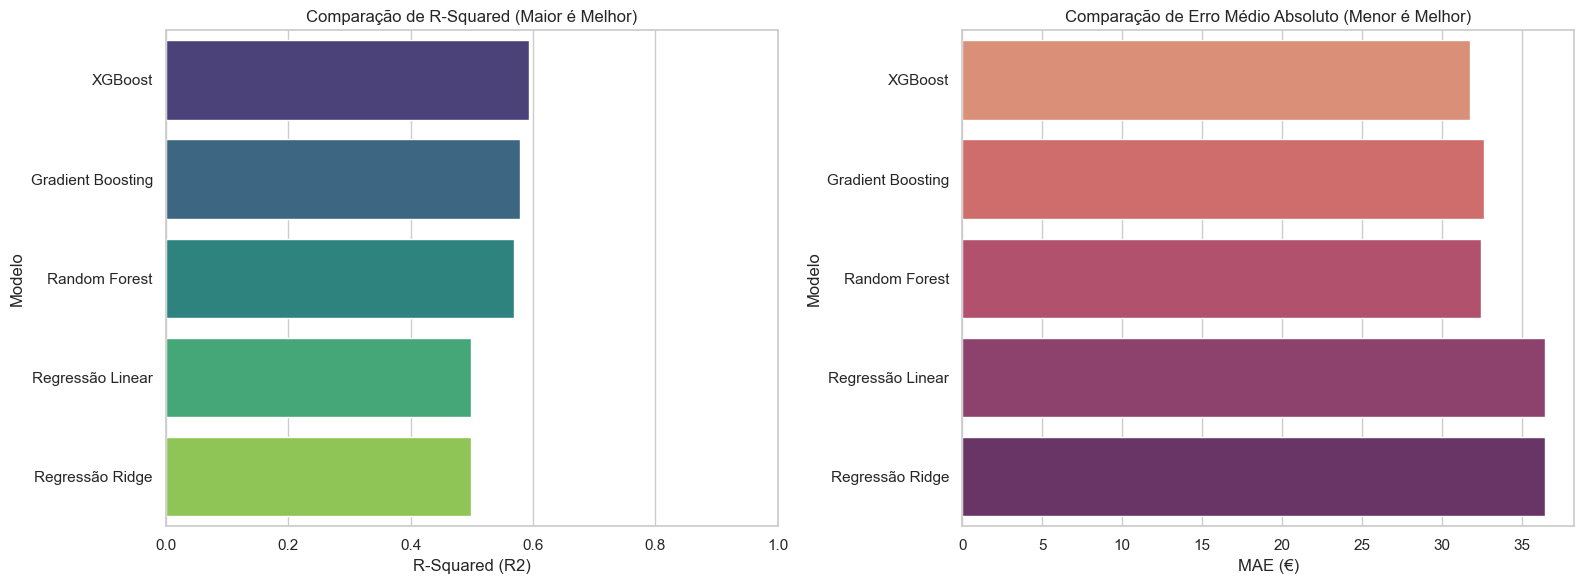

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de R-Squared
sns.barplot(data=df_resultados, x='R-Squared (R2)', y='Modelo', ax=ax[0], palette='viridis')
ax[0].set_title('Comparação de R-Squared (Maior é Melhor)')
ax[0].set_xlim(0, 1)

# Gráfico de MAE
sns.barplot(data=df_resultados, x='MAE (€)', y='Modelo', ax=ax[1], palette='flare')
ax[1].set_title('Comparação de Erro Médio Absoluto (Menor é Melhor)')

plt.tight_layout()
plt.show()

## 9. Análise do Modelo Vencedor (XGBoost)
Após a comparação de vários algoritmos, o **XGBoost** demonstrou ser o modelo mais robusto para este conjunto de dados, apresentando o maior poder explicativo ($R^2$) e a menor margem de erro. 

Vamos isolar este modelo para analisar detalhadamente quais as características do alojamento que têm o maior peso na definição do preço, segundo a perspetiva deste algoritmo avançado.

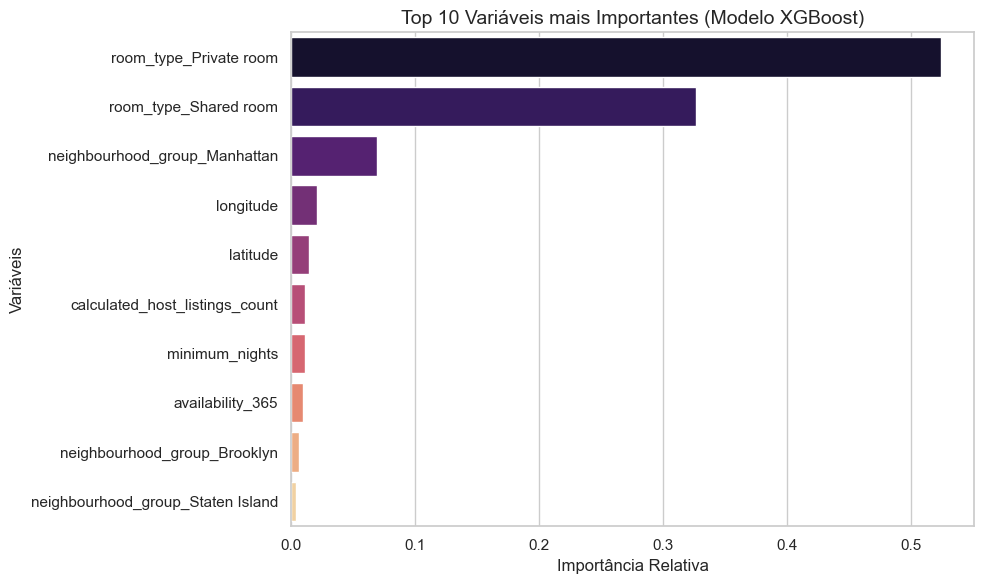

Fim da análise. O modelo está pronto para ser guardado e colocado em produção se necessário.


In [51]:
# Instanciar e treinar o modelo vencedor
modelo_final = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
modelo_final.fit(X_treino_scaled, y_treino)

# Extrair a importância das variáveis do XGBoost
importancias_xgb = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualizar o Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias_xgb.values[:10], y=importancias_xgb.index[:10], hue=importancias_xgb.index[:10], palette='magma', legend=False)
plt.title('Top 10 Variáveis mais Importantes (Modelo XGBoost)', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()

print("Fim da análise. O modelo está pronto para ser guardado e colocado em produção se necessário.")